Correlation Matrix used for feature selction. Target: Direction 

Most recently done on: 09/02/2026

First building a pairwise correlation matrix between features, to find out which features are redundant indicators that carry the same information

Importing all the necessary libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import ta
from ta.trend import SMAIndicator, EMAIndicator, MACD, ADXIndicator, AroonIndicator, KSTIndicator
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator, WilliamsRIndicator
from ta.volatility import BollingerBands, AverageTrueRange, KeltnerChannel
from ta.volume import OnBalanceVolumeIndicator, AccDistIndexIndicator 

import seaborn as sns
import matplotlib.pyplot as plt

# Financial data
import yfinance as yf


Function to fetch and download data (Apple Stock Price) from Yahoo everyday roughly for the past 10 years 

In [2]:
ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01", end ='2026-02-09')

#When you first download stock data using yf.download() the resulting dataframe uses date as the index (row labels)
#Here we are moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

print(data.head())

C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_39492\1177857557.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end ='2026-02-09')
[*********************100%***********************]  1 of 1 completed


Price        Date      Close       High        Low       Open     Volume
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL
0      2015-01-02  24.214890  24.682222  23.776350  24.671147  212818400
1      2015-01-05  23.532721  24.064284  23.346674  23.984549  257142000
2      2015-01-06  23.534933  23.794069  23.173912  23.596948  263188400
3      2015-01-07  23.864946  23.964614  23.632387  23.743129  160423600
4      2015-01-08  24.781893  24.839479  24.075357  24.192745  237458000


In [3]:
#When you download data from yfinance the dataframe can have multiple index columns
#Here we flttern the multi-level column into a single column, making feature enginerring easier
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.head())

Price       Date      Close       High        Low       Open     Volume
0     2015-01-02  24.214890  24.682222  23.776350  24.671147  212818400
1     2015-01-05  23.532721  24.064284  23.346674  23.984549  257142000
2     2015-01-06  23.534933  23.794069  23.173912  23.596948  263188400
3     2015-01-07  23.864946  23.964614  23.632387  23.743129  160423600
4     2015-01-08  24.781893  24.839479  24.075357  24.192745  237458000


Feature Engineering: Here the most common Trend, Momentum, Volatility and Volume indictors are being calculated. 

As the target here is Direction, all features are converted into outputting scale-free ratios instead of raw prices. 

In [4]:
#Define windows to test:
sma_windows = [10, 20, 50]  
ema_windows = [10, 20, 50]
fwma_windows = [10, 20]
aroon_windows = [25, 50]

# Momentum
rsi_windows = [14, 28]       

# Rate of change
roc_windows = [5, 10, 20, 50]
vol_roc_windows = [20, 50]

feature_cols = []

# --- Trend Indicators ---
for w in sma_windows:
    col = f'sma_{w}'
    sma = SMAIndicator(data['Close'], window=w).sma_indicator()
    data[col] = data['Close'] / sma
    feature_cols.append(col)

for w in ema_windows:
    col = f'ema_{w}'
    ema = EMAIndicator(data['Close'], window=w).ema_indicator()
    data[col] = data['Close'] / ema
    feature_cols.append(col)

macd = MACD(data['Close'])
data['macd'] = macd.macd() / data['Close']
data['macd_signal'] = macd.macd_signal() / data['Close']
feature_cols += ['macd', 'macd_signal']

data['adx_14'] = ADXIndicator(data['High'], data['Low'], data['Close'], window=14).adx()
feature_cols.append('adx_14')

def fibonacci_weights(n):
    if n == 1:
        return np.array([1.0])
    
    fib = [1, 2] 
    while len(fib) < n:
        fib.append(fib[-1] + fib[-2])
    
    weights = np.array(fib)
    return weights / weights.sum()

for w in fwma_windows:
    weights = fibonacci_weights(w)
    fwma = data['Close'].rolling(w).apply(lambda x: np.dot(x, weights), raw=True)
    col = f'fwma_{w}'
    data[col] = data['Close'] / fwma
    feature_cols.append(col)


for w in aroon_windows:
    aroon = AroonIndicator(high=data['High'], low=data['Low'], window=w)

    up_col = f'aroon_up_{w}'
    down_col = f'aroon_down_{w}'

    data[up_col] = aroon.aroon_up()
    data[down_col] = aroon.aroon_down()

    feature_cols += [up_col, down_col]

# --- Momentum Indicators ---
for w in rsi_windows:
    col = f'rsi_{w}'
    data[col] = RSIIndicator(data['Close'], window=w).rsi()
    feature_cols.append(col)
    
stoch = StochasticOscillator(data['High'], data['Low'], data['Close'], window=14, smooth_window=3)
data['stoch_14'] = stoch.stoch()
feature_cols.append('stoch_14')

for w in roc_windows:
    col = f'roc_{w}'
    data[col] = ROCIndicator(data['Close'], window=w).roc()
    feature_cols.append(col)

data['williams_r'] = WilliamsRIndicator(
    data['High'], data['Low'], data['Close'], lbp=14
).williams_r()
feature_cols.append('williams_r')

kst = KSTIndicator(
    close=data['Close'],
    roc1=10, roc2=15, roc3=20, roc4=30,
    window1=10, window2=10, window3=10, window4=15
)
data['kst_diff'] = (kst.kst() - kst.kst_sig()) 

feature_cols += ['kst_diff']

# --- Volatility Indicators ---
atr_val = AverageTrueRange(data['High'], data['Low'], data['Close'], window=14).average_true_range()
data['atr_14'] = atr_val / data['Close']
feature_cols.append('atr_14')

bb = BollingerBands(data['Close'], window=20, window_dev=2)
data['bb_width'] = bb.bollinger_wband() / bb.bollinger_mavg()
feature_cols.append('bb_width')

# Garman–Klass volatility (~1 session)
mask = (data[['Open','High','Low','Close']] > 0).all(axis=1)

log_hl = np.log(data.loc[mask, 'High'] / data.loc[mask, 'Low'])
log_co = np.log(data.loc[mask, 'Close'] / data.loc[mask, 'Open'])

rs = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
data.loc[mask, 'GK_vol_session'] = np.sqrt(rs.rolling(20).mean())
feature_cols.append('GK_vol_session')

kc = KeltnerChannel(
    high=data['High'],
    low=data['Low'],
    close=data['Close'],
    window=20,
    window_atr=10
)

data['keltner_width'] = (
    kc.keltner_channel_hband() -
    kc.keltner_channel_lband()
) / data['Close']

feature_cols.append('keltner_width')

# --- Volume Indicators ---

obv_inst = OnBalanceVolumeIndicator(close=data['Close'], volume=data['Volume'])
data['obv_diff'] = obv_inst.on_balance_volume().diff() / data['Volume'].rolling(20).mean()

ad_inst = AccDistIndexIndicator(high=data['High'], low=data['Low'], close=data['Close'], volume=data['Volume'])
data['acc_dist_diff'] = ad_inst.acc_dist_index().diff() / data['Volume'].rolling(20).mean()
feature_cols += ['obv_diff', 'acc_dist_diff']

for w in vol_roc_windows:
    col = f'vol_roc_{w}'
    data[col] = ROCIndicator(data['Volume'], window=w).roc()
    feature_cols.append(col)


data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(method='ffill', inplace=True) 
data.dropna(inplace=True)  

#Direction: 1 if tomorrow's close > today's close else 0
data["Direction"] = (data["Close"].shift(-1) > data["Close"]).astype(int)

#Drop last row 
data = data.iloc[:-1].reset_index(drop=True)

X = data[feature_cols].astype(np.float32)

y = data['Direction'].astype(np.float32)

C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_39492\3200472923.py:146: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


Splitting the features into a training set to prevent a data leak as using the whole dataset would result in future information infleuncing feature selection 

In [5]:
total_size = len(data)

train_size = int(len(data) * 0.7)
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

print(f"Training set   : {len(X_train)} samples ({len(X_train)/total_size:.2%})")
print("Train:", X_train.shape)


Training set   : 1917 samples (69.96%)
Train: (1917, 32)


Using StandardScaler on the training set as data scaling can affect mutual information scores

In [6]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
print("\nScaled X_train Head:")
print(X_train_scaled.head())


Scaled X_train Head:
Price    sma_10    sma_20    sma_50    ema_10    ema_20    ema_50      macd  \
0      0.270717 -0.305897  0.509406  0.267641  0.104047  0.399319  0.150487   
1      0.664307 -0.048091  0.616650  0.561645  0.345156  0.552227  0.197068   
2      0.368353 -0.212974  0.455492  0.179709  0.107296  0.390573  0.206231   
3     -0.050265 -0.467245  0.232065 -0.295124 -0.226873  0.155316  0.162439   
4      0.306466 -0.180831  0.341931  0.070768  0.023052  0.302385  0.155276   

Price  macd_signal    adx_14   fwma_10  ...  williams_r  kst_diff    atr_14  \
0         0.512691 -0.310625  0.840715  ...   -0.047618 -1.488410 -0.156062   
1         0.444627 -0.368995  0.988820  ...    0.534595 -1.597216 -0.176127   
2         0.403149 -0.419809  0.226398  ...    0.254237 -1.552897 -0.211390   
3         0.363096 -0.571058 -0.464757  ...   -0.202280 -1.417868 -0.143263   
4         0.317830 -0.711504  0.144582  ...    0.332556 -1.345673 -0.213813   

Price  bb_width  GK_vol_sess

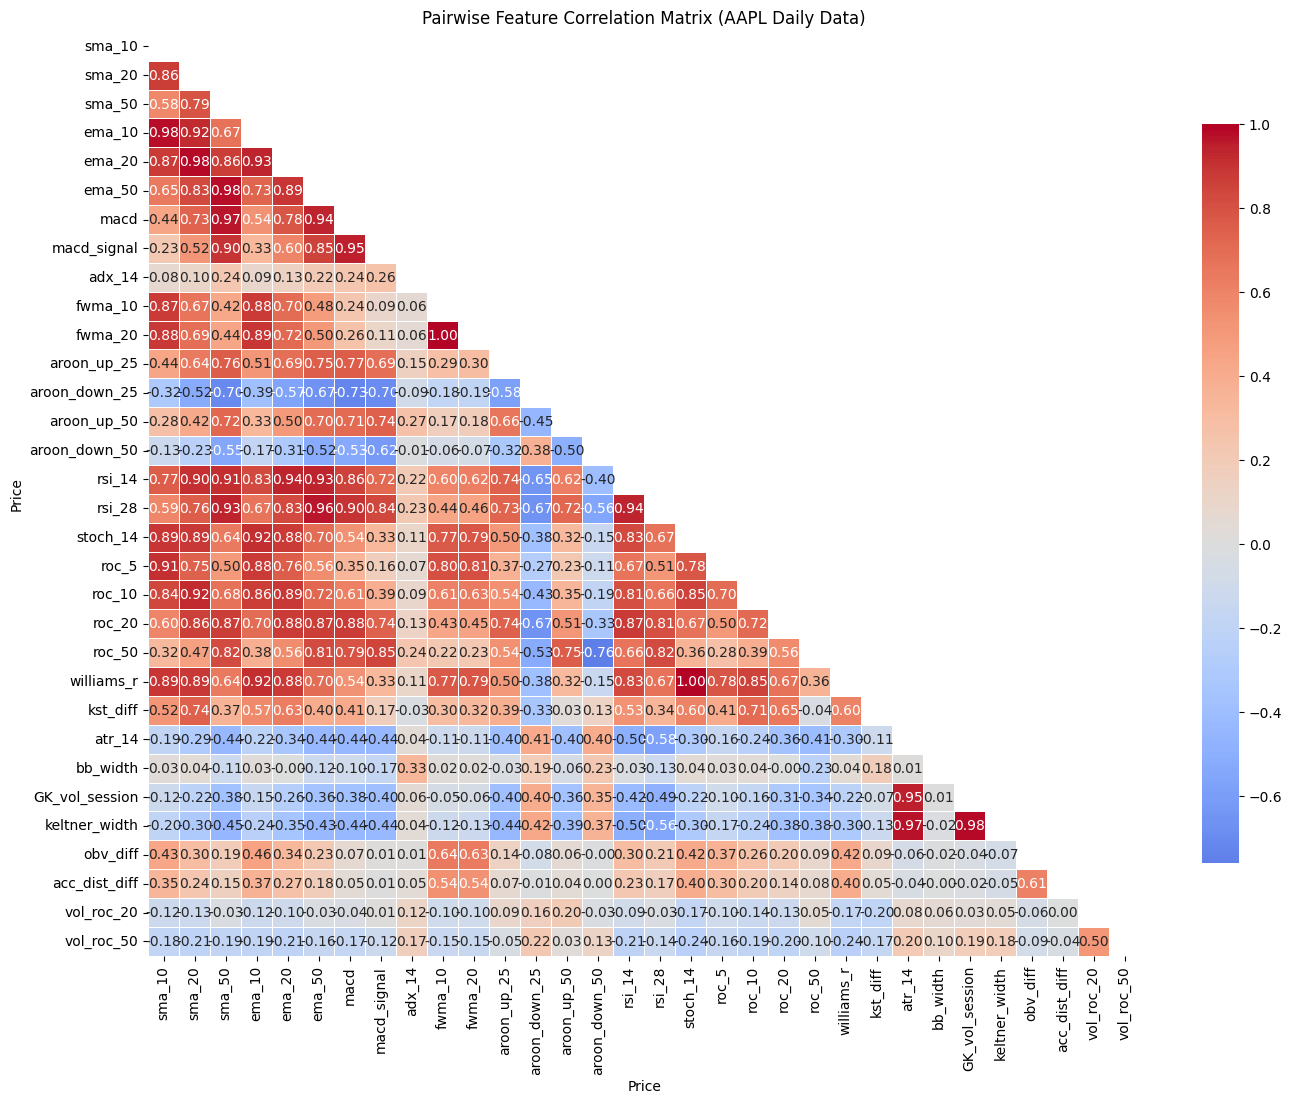

In [7]:
#Calculate the matrix
corr_matrix = X_train_scaled.corr(method='spearman')

#Create a mask for the upper triangle - to remove duplicate values and for a cleaner visual
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))

#Plot with annotations and mask
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,         
    fmt=".2f",           
    cmap="coolwarm", 
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Pairwise Feature Correlation Matrix (AAPL Daily Data)")
plt.show()

In [8]:
#Take the absolute value of the matrix (to catch strong negative correlations too)
abs_corr = corr_matrix.abs()

#Select the upper triangle of the matrix 
upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

#Stack the matrix into a Series and sort by the correlation value
sorted_pairs = upper_tri.stack().sort_values(ascending=False)

#Filter for pairs with a correlation higher than the threshold (e.g., 0.90)
threshold = 0.90
redundant_pairs = sorted_pairs[sorted_pairs > threshold]

print(f"Detected {len(redundant_pairs)} pairs with correlation > {threshold}:")
print(redundant_pairs)

Detected 25 pairs with correlation > 0.9:
Price           Price         
stoch_14        williams_r        1.000000
fwma_10         fwma_20           0.999465
sma_20          ema_20            0.980925
GK_vol_session  keltner_width     0.979785
sma_10          ema_10            0.978339
sma_50          ema_50            0.976314
atr_14          keltner_width     0.969063
sma_50          macd              0.965478
ema_50          rsi_28            0.962613
atr_14          GK_vol_session    0.950480
macd            macd_signal       0.948531
ema_20          rsi_14            0.944267
ema_50          macd              0.936329
rsi_14          rsi_28            0.936300
ema_50          rsi_14            0.934868
sma_50          rsi_28            0.933249
ema_10          ema_20            0.932628
sma_20          ema_10            0.922035
                roc_10            0.918213
ema_10          stoch_14          0.917336
                williams_r        0.917336
sma_50          rsi_14  

Important change: Here as the target is Classification, mutual_info_classif is used instead of mutual_info_regression

Calculating Mutual Information of the correlated features to pick one of the two as candidate features to feed into my models

In [9]:
#Calculating the Mutual Information score between each feature and the target (Direction)
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
mi_results = pd.Series(mi_scores, index=X_train_scaled.columns).sort_values(ascending=False)

to_drop = set()
results = []

#Loop over all redundant feature pairs found by the correlation matrix
for (feat_a, feat_b), corr in redundant_pairs.items():
    # Skip the pair if either is already dropped
    if feat_a in to_drop or feat_b in to_drop:
        continue

    mi_a = mi_results[feat_a]
    mi_b = mi_results[feat_b]

    #Keeping the feature with the higher mutual information with direction
    if mi_a > mi_b:
        loser = feat_b
        winner = feat_a
    else:
        loser = feat_a
        winner = feat_b

    #Drop the lower mutual information feature
    to_drop.add(loser)

    results.append({
        'Feature A': feat_a,
        'Feature B': feat_b,
        'Correlation': round(corr, 4),
        'MI_A': round(mi_a, 6),
        'MI_B': round(mi_b, 6),
        'Winner': winner,
        'Loser': loser
    })

#Compute final feature list - inclduing the features never part of the correlated pairs list
final_features = [f for f in X_train.columns if f not in to_drop]

# --- Print summary ---
print("=" * 60)
print(f"Original Features : {len(X_train.columns)}")
print(f"Features Dropped  : {len(to_drop)}")
print(f"Final Features    : {len(final_features)}")
print("=" * 60)

print("\nDropped Features:")
print(sorted(to_drop))

print("\nKept Features:")
print(final_features)

Original Features : 32
Features Dropped  : 12
Final Features    : 20

Dropped Features:
['GK_vol_session', 'atr_14', 'ema_10', 'ema_50', 'fwma_20', 'macd', 'rsi_14', 'rsi_28', 'sma_10', 'sma_20', 'sma_50', 'stoch_14']

Kept Features:
['ema_20', 'macd_signal', 'adx_14', 'fwma_10', 'aroon_up_25', 'aroon_down_25', 'aroon_up_50', 'aroon_down_50', 'roc_5', 'roc_10', 'roc_20', 'roc_50', 'williams_r', 'kst_diff', 'bb_width', 'keltner_width', 'obv_diff', 'acc_dist_diff', 'vol_roc_20', 'vol_roc_50']


In [10]:
final_mi = mi_results[final_features].sort_values(ascending=False)

print("\nFinal Features Ranked By Mutual Information")
print("=" * 60)

for i, (feat, score) in enumerate(final_mi.items(), 1):
    print(f"{i:2d}. {feat:20s} MI = {score:.6f}")


Final Features Ranked By Mutual Information
 1. keltner_width        MI = 0.021119
 2. williams_r           MI = 0.010388
 3. bb_width             MI = 0.009973
 4. roc_5                MI = 0.005854
 5. fwma_10              MI = 0.005340
 6. macd_signal          MI = 0.004764
 7. aroon_down_50        MI = 0.004512
 8. roc_50               MI = 0.003027
 9. ema_20               MI = 0.001964
10. aroon_up_50          MI = 0.001380
11. acc_dist_diff        MI = 0.000616
12. adx_14               MI = 0.000000
13. roc_20               MI = 0.000000
14. roc_10               MI = 0.000000
15. aroon_down_25        MI = 0.000000
16. aroon_up_25          MI = 0.000000
17. kst_diff             MI = 0.000000
18. obv_diff             MI = 0.000000
19. vol_roc_20           MI = 0.000000
20. vol_roc_50           MI = 0.000000
